# View Data

In [2]:
import numpy as np
import torch
from matplotlib import pyplot as plt
from PythonTools.load_mask import load_torch_tensor
import cv2

## View the mask

(np.float64(-0.5), np.float64(639.5), np.float64(399.5), np.float64(-0.5))

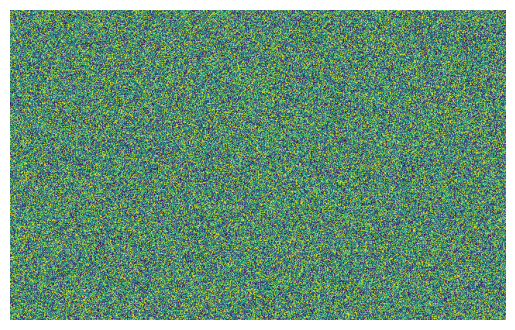

In [3]:
mask = load_torch_tensor('2026_01_27/16/categorical/fashion/example/train/epoch_19/mask.pt')
mask = np.argmax(mask, axis=-1)

# View mask
plt.imshow(mask)
plt.axis('off')

## View the dataset

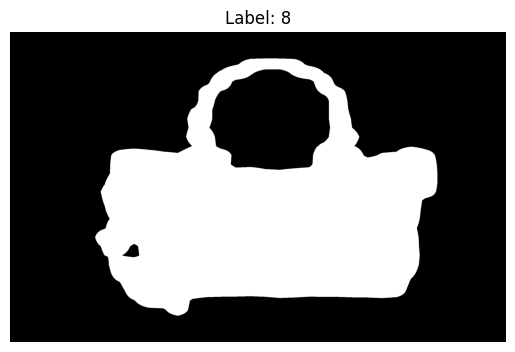

In [4]:
dataset = np.load('FashionDatasets/Images/Test_Dataset.npy')
labels  = np.load('FashionDatasets/Labels/Test_Dataset.npy')

idx = 0
image = dataset[idx].squeeze() # Resize the image

# Adding 3px padding to the image
image = np.pad(image, ((3, 3), (3, 3)), mode='constant', constant_values=0)

image = cv2.resize(image, (2560, 1600))
image = 1 - image
image = image > 0.8
image = 1 - image

plt.imshow(image,cmap='grey')
plt.axis('off')
plt.title(f'Label: {np.argmax(labels[idx])}')
plt.show()

# View the Images

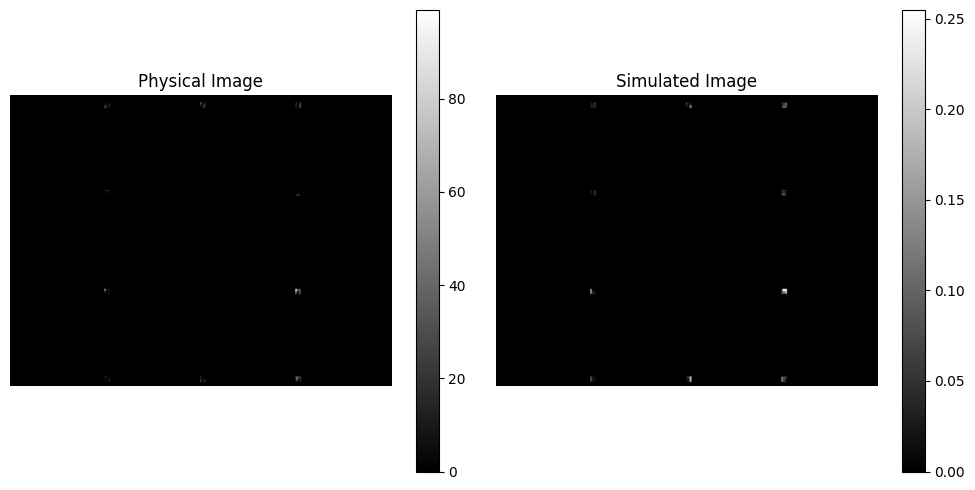

[ WARN:0@137.745] global loadsave.cpp:1063 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


True

In [11]:
phy_image = cv2.imread('2026_01_27/16/categorical/fashion/example/images/sample_4800040_8_8.png', cv2.IMREAD_GRAYSCALE)
sim_image = np.load('cropped_images.npy')[2].squeeze()
detector = np.load('source/Assets/phy8_10.npy').sum(axis=0).squeeze()

phy_image = phy_image.astype(np.float32)
sim_image = sim_image.astype(np.float32)

phy_image *= detector
sim_image *= detector

def build_image(image):
        images = []
        for i in range(4):
            block = image[i*50:(i+1)*50, :]
            images.append(block)

            if i < 3:
                # Add 104x672 block of zeros between blocks
                zero_block = np.zeros((104, 672), dtype=np.uint8)
                images.append(zero_block)
        return np.vstack(images)

phy_image = build_image(phy_image)
sim_image = build_image(sim_image)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(phy_image, cmap='gray')
plt.title('Physical Image')
plt.colorbar()
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sim_image, cmap='gray')
plt.title('Simulated Image')
plt.axis('off')
plt.colorbar()
plt.tight_layout()
plt.show()

# Save the physical image
cv2.imwrite('fmnist_2_2_phy.png', phy_image)

# Save the simulated image
cv2.imwrite('fmnist_2_2_sim.png', sim_image * 255)  # Scale to [0, 255] for saving as PNG




## View Result

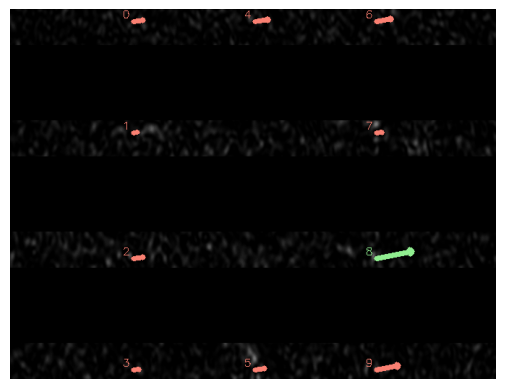

In [35]:
image = cv2.imread('2026_01_27/16/categorical/fashion/example/images/sample_4800040_8_8.png', cv2.IMREAD_GRAYSCALE)

def create_combined_image(image):

    # Load the detector
    detector = np.load('source/Assets/phy8_10.npy')
    values = []
    for i in range(10):
        det = detector[i].squeeze()
        value = np.sum(image * det)
        values.append(value)
    values = np.array(values)# / (255.0 * 10 * 2)

    # Normalize values for better visualization
    values = values / np.max(values)  # Normalize to [0, 1]

    #values /= (255.0 * 10 * 10)
    #values = torch.softmax(torch.from_numpy(values), dim=0).numpy()
    #print(f'argmax: {np.argmax(values)}, values: {values}')


    # Create a detector_image by summing the detector values
    detector_image = np.sum(detector, axis=0).squeeze()


    # Image is 200x672
    # Split into 50x672 blocks and add 
    def build_image(image):
        images = []
        for i in range(4):
            block = image[i*50:(i+1)*50, :]
            images.append(block)

            if i < 3:
                # Add 104x672 block of zeros between blocks
                zero_block = np.zeros((104, 672), dtype=np.uint8)
                images.append(zero_block)
        return np.vstack(images)

    # Concatenate all blocks vertically
    final_image = build_image(image)
    built_detector_image = build_image(detector_image)

    # Convert to color image for colored arrows
    final_image_color = cv2.cvtColor(final_image, cv2.COLOR_GRAY2BGR)

    # Find the index with max value for green arrow
    max_idx = np.argmax(values)

    # Place arrows at detector locations - find center of each detector region
    for i in range(10):
        det = detector[i].squeeze()
        det_built = build_image(det)
        
        # Find center of mass of the detector region
        mask = (det_built > 0.5).astype(np.uint8)
        moments = cv2.moments(mask)
        
        if moments['m00'] > 0:  # Check if there's any area
            cx = int(moments['m10'] / moments['m00'])
            cy = int(moments['m01'] / moments['m00'])
            
            # Scale arrow length by value (multiply by a constant for visibility)
            arrow_length = int(values[i] * 50)  # Scale up for visibility
            vertical_offset = int(values[i] * 10)  # Scale vertical component
            
            # Set color: lightgreen for max, salmon for others (BGR format)
            color = (144, 238, 144) if i == max_idx else (114, 128, 250)
            
            # Place a single arrow at the center of the detector region with thicker stem and larger arrow head
            cv2.arrowedLine(final_image_color, (cx, cy), (cx+arrow_length, cy-vertical_offset), color, 5, tipLength=0.1)
            
            # Add label marker next to the stem of the arrow
            label_x = cx - 15  # Position to the left of the stem
            label_y = cy - 5   # Slightly above the stem
            cv2.putText(final_image_color, str(i), (label_x, label_y), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    return final_image_color

final_image_color = create_combined_image(image)

plt.imshow(cv2.cvtColor(final_image_color, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

0.007843138 0.28627452


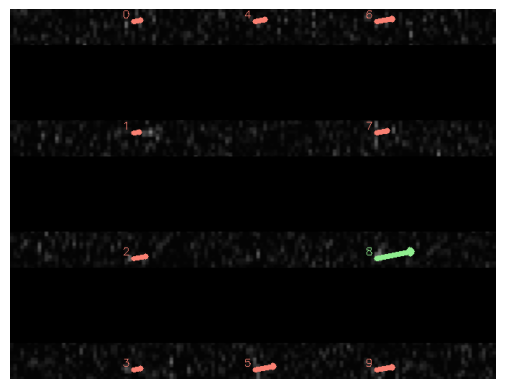

In [36]:
image = np.load('cropped_images.npy')
image = image[2].squeeze()
print(image.min(), image.max())
image = image / np.max(image)
image = image * 255.0
image = image.astype(np.uint8)

# Increase contrast
alpha = 0.5  # Contrast control (1.0-3.0)
beta = 1.0     # Brightness control
image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)

final_image_color = create_combined_image(image)

plt.imshow(cv2.cvtColor(final_image_color, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()